In [ ]:
# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Load the dataset

In [ ]:
df = pd.read_csv("/content/Chocolate Sales.csv")

In [ ]:
# Display first five rows

In [ ]:
df = df[['Country', 'Product', 'Date', 'Amount']]
df.head()

,Country,Product,Date,Amount
0,UK,Mint Chip Choco,04/01/2022,"$5,320.00"
1,India,85% Dark Bars,01/08/2022,"$7,896.00"
2,India,Peanut Butter Cubes,07/07/2022,"$4,501.00"
3,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00"
4,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00"


In [ ]:
# Randomly Select 500 Rows

In [ ]:
df = df.sample(n=500, random_state=42)
df.reset_index(drop=True, inplace=True)

In [ ]:
# Number of rows and columns

In [ ]:
df.shape

(500, 4)

In [ ]:
# Display all column names

In [ ]:
df.columns

Index(['Country', 'Product', 'Date', 'Amount'], dtype='object')

In [ ]:
# Basic information about dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Country  500 non-null    object
 1   Product  500 non-null    object
 2   Date     500 non-null    object
 3   Amount   500 non-null    object
dtypes: object(4)
memory usage: 15.8+ KB


In [ ]:
# Summary statistics

In [ ]:
df.describe(include="all")

,Country,Product,Date,Amount
count,500,500,500,500
unique,6,22,296,487
top,Australia,Almond Choco,26/01/2022,"$2,282.00"
freq,99,30,5,2


In [ ]:
# Check missing values

In [ ]:
df.isnull().sum()

,0
Country,0
Product,0
Date,0
Amount,0


In [ ]:
# Check duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove duplicate rows if available

In [ ]:
df = df.drop_duplicates()

In [ ]:
# Number of unique values in each column

In [ ]:
df.nunique()

,0
Country,6
Product,22
Date,296
Amount,487


In [ ]:
# Remove '$' and ',' from Amount column

In [ ]:
df["Amount"] = (
    df["Amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [ ]:
# Check Data Types Again

In [ ]:
df.dtypes

,0
Country,object
Product,object
Date,object
Amount,float64


In [ ]:
# Display Clean Dataset

In [ ]:
df.head()

,Country,Product,Date,Amount
0,New Zealand,Peanut Butter Cubes,28/01/2023,5360.89
1,Canada,85% Dark Bars,20/04/2023,1639.01
2,USA,Eclairs,18/03/2024,9446.67
3,Canada,White Choc,03/03/2023,3398.51
4,USA,Caramel Stuffed Bars,14/02/2024,1115.84


In [ ]:
# Distribution of sales amount

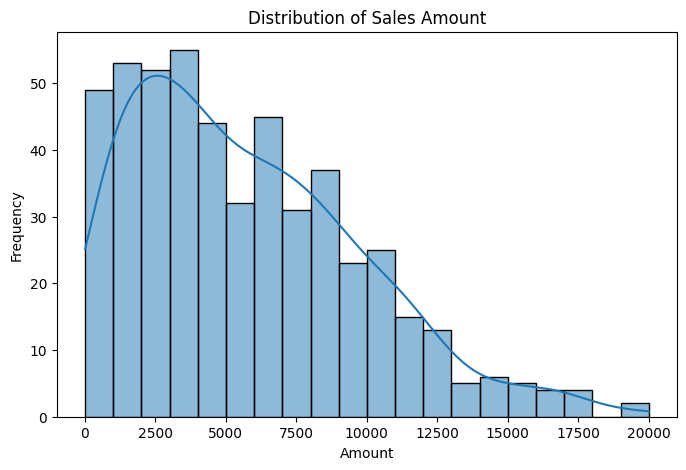

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=20, kde=True)

plt.title("Distribution of Sales Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Detect outliers using Boxplot

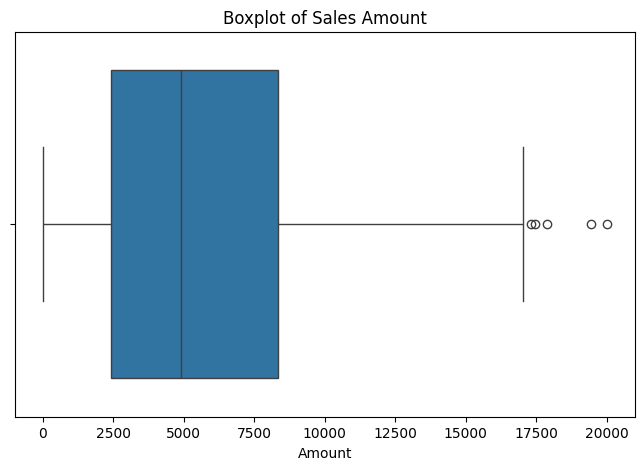

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot of Sales Amount")
plt.show()

In [ ]:
# Total sales by country

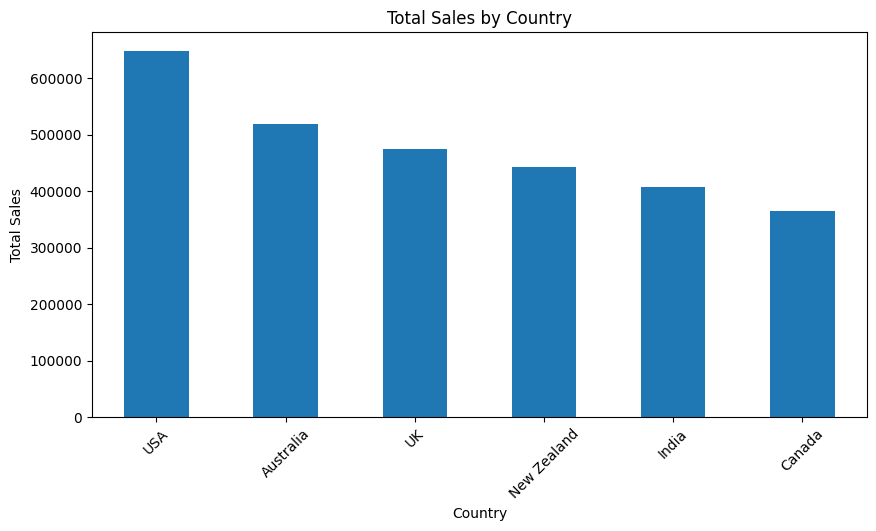

In [ ]:
country_sales = df.groupby("Country")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

country_sales.plot(kind="bar")

plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Total sales by product

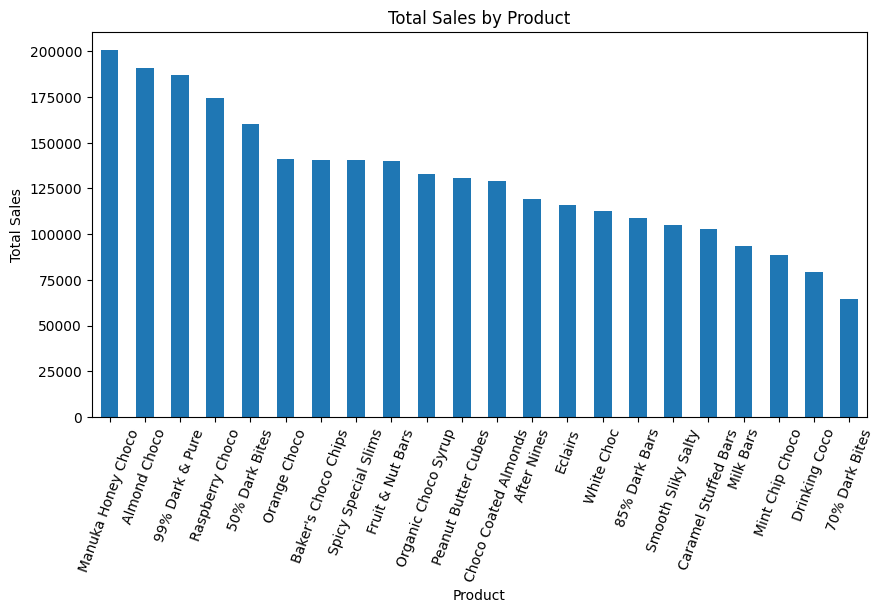

In [ ]:
product_sales = df.groupby("Product")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=70)

plt.show()

In [ ]:
# Display top 10 highest sales

In [ ]:
df.nlargest(10, "Amount")

,Country,Product,Date,Amount
486,USA,Manuka Honey Choco,16/02/2024,19995.68
223,Canada,After Nines,13/01/2024,19449.02
300,USA,Mint Chip Choco,15/02/2024,17866.48
74,USA,Baker's Choco Chips,11/08/2022,17465.00
363,USA,Manuka Honey Choco,16/02/2023,17297.66
401,USA,Raspberry Choco,15/04/2024,17037.09
206,UK,Smooth Sliky Salty,04/03/2024,16733.76
470,India,Organic Choco Syrup,08/03/2023,16717.26
318,UK,Almond Choco,28/07/2023,16707.88
11,India,Organic Choco Syrup,08/03/2022,16569.00


In [ ]:
# Display lowest 10 sales

In [ ]:
df.nsmallest(10, "Amount")

,Country,Product,Date,Amount
298,UK,99% Dark & Pure,07/03/2024,8.16
111,India,Peanut Butter Cubes,14/04/2024,33.68
258,New Zealand,Orange Choco,01/04/2024,51.98
282,USA,Spicy Special Slims,29/04/2022,77.00
29,Australia,Drinking Coco,19/07/2022,91.00
129,Australia,Drinking Coco,19/07/2023,94.19
485,Australia,Drinking Coco,19/07/2024,105.06
463,India,Fruit & Nut Bars,26/01/2022,168.00
182,Australia,70% Dark Bites,24/06/2023,237.57
57,Australia,70% Dark Bites,24/06/2022,238.00


In [ ]:
# Average sales of each country

In [ ]:
df.groupby("Country")["Amount"].mean().sort_values(ascending=False)

,Amount
Country,
USA,6756.618125
UK,6322.416800
Canada,5534.667424
New Zealand,5474.928889
Australia,5240.510808
India,4912.218675


In [ ]:
# Average sales of each product

In [ ]:
df.groupby("Product")["Amount"].mean().sort_values(ascending=False)

,Amount
Product,
Manuka Honey Choco,7712.752692
Baker's Choco Chips,7406.826842
Mint Chip Choco,7401.150000
Raspberry Choco,6987.159200
Almond Choco,6361.056333
99% Dark & Pure,6225.262333
50% Dark Bites,6160.732308
Fruit & Nut Bars,6080.278696
Caramel Stuffed Bars,6039.298235


In [ ]:
# Convert Date column, Extract Month and Year

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df.head()

/tmp/ipykernel_1401/3726362342.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


,Country,Product,Date,Amount,Month,Year
0,New Zealand,Peanut Butter Cubes,2023-01-28,5360.89,1,2023
1,Canada,85% Dark Bars,2023-04-20,1639.01,4,2023
2,USA,Eclairs,2024-03-18,9446.67,3,2024
3,Canada,White Choc,2023-03-03,3398.51,3,2023
4,USA,Caramel Stuffed Bars,2024-02-14,1115.84,2,2024


In [ ]:
# Select input features & Target

In [ ]:
X = df[["Country", "Product", "Month", "Year"]]

y = df["Amount"]

In [ ]:
# Split Dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train_original, X_test_original, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
# Encoding training data, testing data

In [ ]:
X_train = pd.get_dummies(
    X_train_original,
    columns=["Country", "Product"],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test_original,
    columns=["Country", "Product"],
    drop_first=True
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
# Shape

In [ ]:
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (400, 28)
Testing Shape  : (100, 28)


In [ ]:
# Creat model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
# Train model

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Prediction

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Compare results

In [ ]:
comparison = X_test_original.copy()

comparison["Actual Amount"] = y_test.values
comparison["Predicted Amount"] = y_pred

comparison["Error"] = (
    comparison["Predicted Amount"]
    - comparison["Actual Amount"]
)

comparison.head(10)

,Country,Product,Month,Year,Actual Amount,Predicted Amount,Error
361,India,White Choc,3,2023,2183.68,4525.055052,2341.375052
73,UK,Almond Choco,6,2023,11258.39,7147.801593,-4110.588407
374,UK,Raspberry Choco,1,2022,12635.00,6786.803744,-5848.196256
155,UK,Smooth Sliky Salty,7,2023,5828.22,5842.821866,14.601866
104,UK,Peanut Butter Cubes,4,2023,2362.01,7333.697887,4971.687887
394,Canada,Organic Choco Syrup,1,2024,9479.63,6243.383875,-3236.246125
377,Australia,Organic Choco Syrup,1,2022,994.00,5077.690690,4083.690690
124,Australia,After Nines,3,2024,8265.41,6148.373569,-2117.036431
68,Australia,85% Dark Bars,7,2022,4200.00,3066.895640,-1133.104360
450,UK,Drinking Coco,3,2022,973.00,4637.212218,3664.212218


In [ ]:
# Evaluation (Mean Absolute Error, Root Mean Squared Error, R-Squared Score)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 3311.1569914296706
Root Mean Squared Error (RMSE): 4200.325135823556
R² Score: -0.060407444793044496


In [ ]:
# Predict new data

In [ ]:
new_data = pd.DataFrame({
    "Country": ["India"],
    "Product": ["Milk Bars"],
    "Month": [6],
    "Year": [2022]
})

new_data = pd.get_dummies(
    new_data,
    columns=["Country", "Product"],
    drop_first=True
)

new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

prediction = model.predict(new_data)

print("Predicted Sales Amount:", prediction[0])

Predicted Sales Amount: 5221.190919894725
